# ETL + EDA: Encuesta de Hogares (ODS 1)

Pipeline completo: Identificación -> Extracción -> Transformación -> Modelo dimensional -> Carga a Postgres -> EDA.

Esquema de galaxia: Usamos un esquema de galaxia para poder anexar una nueva tabla de hechos de `fact_personas` más adelante sin duplicar atributos: `dim_geografia`, `dim_tiempo` y `dim_hogar`, que quedan como dimensiones compartidas entre `fact_hogares` y el `fact_personas`, construido a partir del CSV de personas. `dim_hogar` actúa de puente, ya que identifica el hogar (`directorio`, `secuencia_p`) y su tenencia de vivienda (`p5090`) una sola vez, en vez de repetirlos en cada fila de persona.


In [1]:
# Instalación de librerías necesarias
!pip install psycopg2-binary sqlalchemy -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 61.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from getpass import getpass
from sqlalchemy import create_engine, text
from google.colab import drive

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [3]:
usuario_pg = "postgres.yvqxjtqaghpakklellqr"
host_pg = "aws-0-ca-central-1.pooler.supabase.com"
db_pg = "postgres"
password_pg = getpass("Contraseña de Postgres: ")

conexion_pg = f"postgresql+psycopg2://{usuario_pg}:{password_pg}@{host_pg}:5432/{db_pg}"
engine = create_engine(conexion_pg)


Contraseña de Postgres: ··········


## 1. Extracción

In [4]:
# Definir ruta del CSV en Google Drive
drive.mount('/content/drive')
ruta_base = "/content/drive/My Drive/Actividades ETL/"
ruta_csv = ruta_base + "Hogares.csv"


df = pd.read_csv(ruta_csv)
print(f"Filas: {df.shape[0]:,}, Columnas: {df.shape[1]}")
df.head()


Mounted at /content/drive
Filas: 276,666, Columnas: 23


,directorio,secuencia_p,mes,nper,npersug,clase,ingtotug,dominio,lp,li,...,ingtotarr,ingpcug,pobre,indigente,npobres,nindigentes,fex_c,ciudad_sinam,dpto,fex_dpto
0,8086872,1,1,1,1,2,"1,040,000.00",RURAL,"308,654.56","182,935.53",...,"1,390,000.00","1,390,000.00",0,0,0,0,182.06,NaN,Bolívar,80.34
1,8086874,1,1,3,3,2,"2,320,833.33",RURAL,"308,654.56","182,935.53",...,"2,520,833.33","840,277.78",0,0,0,0,100.71,NaN,Bolívar,64.57
2,8086875,1,1,1,1,2,"2,784,000.00",RURAL,"308,654.56","182,935.53",...,"3,084,000.00","3,084,000.00",0,0,0,0,175.34,NaN,Bolívar,69.00
3,8086876,1,1,3,3,2,"2,686,666.67",RURAL,"308,654.56","182,935.53",...,"2,986,666.67","995,555.56",0,0,0,0,201.67,NaN,Bolívar,145.28
4,8086877,1,1,3,3,2,"3,385,333.33",RURAL,"308,654.56","182,935.53",...,"3,685,333.33","1,228,444.44",0,0,0,0,208.94,NaN,Bolívar,122.44


In [5]:
# Verificación rápida para saber si los rangos de li y lp son correctos según dice el DANE
print("Duplicados por (directorio, secuencia_p):", df.duplicated(subset=["directorio", "secuencia_p"]).sum())

rangos_oficiales = {"li": (182935.52974, 316815.18966), "lp": (308654.56309, 675919.2315)}
for col, (lo, hi) in rangos_oficiales.items():
    obs_lo, obs_hi = df[col].min(), df[col].max()
    print(f"{col}: observado [{obs_lo:.2f}, {obs_hi:.2f}] -> {'OK' if obs_lo >= lo*0.99 and obs_hi <= hi*1.01 else 'REVISAR'}")


Duplicados por (directorio, secuencia_p): 0
li: observado [182935.53, 316815.19] -> OK
lp: observado [308654.56, 675919.23] -> OK


## 2. Transformación

- `p5100`, `p5130`: se dejan como NULL numérico (representan "no aplica" según el tipo de tenencia, no dato faltante real), porque mezclar texto tipo "No aplica" en una columna de dinero rompería el tipo de dato para sumas/promedios. Quedan fuera de `fact_hogares` a propósito porque no responden a ninguna de las 3 preguntas.
- `ciudad_sinam` sí es texto, así que sus nulos se rellenan con `"No aplica"` de forma segura.
- `p5090`: se traduce a `categoria_tenencia` legibley esta sí viaja a `dim_hogar`, para poder agrupar por tipo de tenencia directo en SQL.
- `brecha_pobreza`/`brecha_pct_pobreza` y `brecha_indigencia`/`brecha_pct_indigencia`: razón de brecha de ingreso — `(línea - ingpcug) / línea * 100`. Positivo = qué tan por debajo está el hogar de esa línea,  negativo = está por encima. Ambas viajan a `fact_hogares` y la de indigencia es la variable central de la Pregunta 3.
- `tamaño_hogar_rango` (bucket de `nper`) y `categoria_tenencia` van a `dim_hogar`. `tipo_zona` y `clase_desc` van a `dim_geografia`. Así el EDA puede agrupar por estas categorías directo en SQL, sin tener que reconstruir la lógica con `CASE WHEN` en cada query.
- Variables monetarias redondeadas a 2 decimales, como dice el diccionario oficial del DANE.
- `ingtotug_outlier`: flag booleano para hogares con ingreso total <= 0 (no se eliminan, solo se marcan para que el análisis decida qué hacer con ellos).
- `mes`, `clase`, `p5090` se tipan como `category` (pocos valores posibles, se repiten miles de veces). `pobre`/`indigente` se dejan en `int64` a propósito, porque `fact_hogares` los carga en columnas `INTEGER` de Postgres.


In [6]:
df["ciudad_sinam"] = df["ciudad_sinam"].fillna("No aplica")

mapa_tenencia = {
    1: "Propia, totalmente pagada", 2: "Propia, la están pagando",
    3: "En arriendo o subarriendo", 4: "En usufructo",
    5: "Posesión sin título", 6: "Propiedad colectiva", 7: "Otra",
}
df["categoria_tenencia"] = df["p5090"].map(mapa_tenencia)

df["clase_desc"] = df["clase"].map({1: "Urbano", 2: "Rural"})
df["tipo_zona"] = np.where(
    df["clase"] == 2, "Rural",
    np.where(df["dominio"] == "RESTO URBANO", "Resto urbano", "Ciudad capital")
)

df["tamano_hogar_rango"] = pd.cut(df["nper"], bins=[0, 2, 4, 100], labels=["1-2", "3-4", "5+"]).astype(str)

# brecha_pobreza / brecha_pct_pobreza y brecha_indigencia / brecha_pct_indigencia: ambas viajan a fact_hogares
df["brecha_pobreza"] = (df["lp"] - df["ingpcug"]) / df["lp"]
df["brecha_pct_pobreza"] = (df["brecha_pobreza"] * 100).round(2)

df["brecha_indigencia"] = (df["li"] - df["ingpcug"]) / df["li"]
df["brecha_pct_indigencia"] = (df["brecha_indigencia"] * 100).round(2)

cols_monetarias = ["ingtotug", "ingtotarr", "ingpcug", "lp", "li", "p5100", "p5130"]
df[cols_monetarias] = df[cols_monetarias].round(2)

# Outliers: hogares con ingreso total <= 0 -- se marcan, no se eliminan (solo viven en df, no en fact_hogares)
df["ingtotug_outlier"] = df["ingtotug"] <= 0
print("Hogares con ingtotug <= 0 (marcados como outlier):", df["ingtotug_outlier"].sum())

# Tipado: columnas de pocos valores posibles pasan a category (memoria + velocidad en groupby).
# pobre/indigente se dejan como int64 (no bool) porque fact_hogares las carga en columnas
# INTEGER de Postgres, y Postgres no castea automáticamente bool -> integer al insertar.
df["mes"] = df["mes"].astype("category")
df["clase"] = df["clase"].astype("category")
df["p5090"] = df["p5090"].astype("category")

# Validación de consistencia (solo diagnóstico, no se modifica nada): nper vs. npersug
n_diff = (df["nper"] != df["npersug"]).sum()
print(f"Filas donde nper != npersug: {n_diff} ({n_diff / len(df) * 100:.2f}%)")

df[["clase_desc", "tipo_zona", "tamano_hogar_rango", "categoria_tenencia", "brecha_pct_pobreza", "brecha_pct_indigencia", "ingtotug_outlier"]].head()


Hogares con ingtotug <= 0 (marcados como outlier): 2195
Filas donde nper != npersug: 1225 (0.44%)


,clase_desc,tipo_zona,tamano_hogar_rango,categoria_tenencia,brecha_pct_pobreza,brecha_pct_indigencia,ingtotug_outlier
0,Rural,Rural,1-2,"Propia, totalmente pagada",-350.34,-659.83,False
1,Rural,Rural,3-4,En usufructo,-172.24,-359.33,False
2,Rural,Rural,1-2,"Propia, totalmente pagada",-899.18,"-1,585.84",False
3,Rural,Rural,3-4,"Propia, totalmente pagada",-222.55,-444.21,False
4,Rural,Rural,3-4,"Propia, totalmente pagada",-298.00,-571.52,False


## 3. Modelo dimensional (esquema galaxia / constelación)

Defiminimos dos tablas de hechos que van a compartir dimensiones: `fact_hogares` (este notebook) y el  `fact_personas` (a partir del CSV de personas, que se agrega en otra fase). Por eso `dim_geografia`, `dim_tiempo` y `dim_hogar` se construyen como dimensiones conformadas,en un mismo grano y mismas llaves (`id_geografia`, `id_tiempo`, `id_hogar`) sin importar cuál tabla de hechos las consulte.

`dim_hogar` guarda la identificación del hogar (`directorio`, `secuencia_p`), el código de tenencia (`p5090`) y ahora también las columnas legibles derivadas de él (`categoria_tenencia`, `tamano_hogar_rango`) para que `fact_personas` pueda enlazar cada persona a su hogar por `id_hogar` sin duplicar esos datos por cada integrante. `dim_geografia` incluye igual sus columnas legibles (`clase_desc`, `tipo_zona`) para poder agrupar por ellas directo en SQL.


In [7]:
dim_geografia = df[["dpto", "dominio", "ciudad_sinam", "clase", "clase_desc", "tipo_zona"]].drop_duplicates().reset_index(drop=True)
dim_geografia.insert(0, "id_geografia", range(1, len(dim_geografia) + 1))

dim_hogar = df[["directorio", "secuencia_p", "p5090", "categoria_tenencia", "tamano_hogar_rango"]].drop_duplicates().reset_index(drop=True)
dim_hogar.insert(0, "id_hogar", range(1, len(dim_hogar) + 1))

dim_tiempo = df[["mes"]].drop_duplicates().sort_values("mes").reset_index(drop=True)
dim_tiempo.insert(0, "id_tiempo", range(1, len(dim_tiempo) + 1))
nombres_mes = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
               7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
dim_tiempo["nombre_mes"] = dim_tiempo["mes"].map(nombres_mes)

print("dim_geografia:", dim_geografia.shape, "| dim_hogar:", dim_hogar.shape, "| dim_tiempo:", dim_tiempo.shape)


dim_geografia: (76, 7) | dim_hogar: (276666, 6) | dim_tiempo: (12, 3)


In [8]:
fact = df.merge(dim_geografia, on=["dpto", "dominio", "ciudad_sinam", "clase", "clase_desc", "tipo_zona"], how="left")
fact = fact.merge(dim_hogar, on=["directorio", "secuencia_p", "p5090", "categoria_tenencia", "tamano_hogar_rango"], how="left")
fact = fact.merge(dim_tiempo[["id_tiempo", "mes"]], on="mes", how="left")

fact_hogares = fact[[
    "id_tiempo", "id_geografia", "id_hogar",
    "nper",  # tamaño del hogar -- necesario para responder la Pregunta 1 con SQL
    "ingtotug", "ingpcug", "lp", "li",
    "brecha_pobreza", "brecha_pct_pobreza",
    "brecha_indigencia", "brecha_pct_indigencia",
    "pobre", "indigente", "npobres", "nindigentes",
    "fex_c",
]].copy()

# Ningún hogar debe quedar sin id de alguna dimensión
print(fact_hogares[["id_tiempo", "id_geografia", "id_hogar"]].isnull().sum())
fact_hogares.head()


id_tiempo       0
id_geografia    0
id_hogar        0
dtype: int64


,id_tiempo,id_geografia,id_hogar,nper,ingtotug,ingpcug,lp,li,brecha_pobreza,brecha_pct_pobreza,brecha_indigencia,brecha_pct_indigencia,pobre,indigente,npobres,nindigentes,fex_c
0,1,1,1,1,"1,040,000.00","1,390,000.00","308,654.56","182,935.53",-3.50,-350.34,-6.60,-659.83,0,0,0,0,182.06
1,1,1,2,3,"2,320,833.33","840,277.78","308,654.56","182,935.53",-1.72,-172.24,-3.59,-359.33,0,0,0,0,100.71
2,1,1,3,1,"2,784,000.00","3,084,000.00","308,654.56","182,935.53",-8.99,-899.18,-15.86,"-1,585.84",0,0,0,0,175.34
3,1,1,4,3,"2,686,666.67","995,555.56","308,654.56","182,935.53",-2.23,-222.55,-4.44,-444.21,0,0,0,0,201.67
4,1,1,5,3,"3,385,333.33","1,228,444.44","308,654.56","182,935.53",-2.98,-298.00,-5.72,-571.52,0,0,0,0,208.94


## 4. Carga a Postgres

In [24]:
with engine.connect() as conn:
    conn.execute(text("""
        DROP TABLE IF EXISTS fact_hogares;
        DROP TABLE IF EXISTS dim_hogar;
        DROP TABLE IF EXISTS dim_geografia;
        DROP TABLE IF EXISTS dim_tiempo;

        CREATE TABLE dim_geografia (
            id_geografia INTEGER PRIMARY KEY,
            dpto TEXT, dominio TEXT, ciudad_sinam TEXT, clase INTEGER,
            clase_desc TEXT, tipo_zona TEXT
        );

        CREATE TABLE dim_hogar (
            id_hogar INTEGER PRIMARY KEY,
            directorio BIGINT, secuencia_p INTEGER, p5090 INTEGER,
            categoria_tenencia TEXT, tamano_hogar_rango TEXT
        );

        CREATE TABLE dim_tiempo (
            id_tiempo INTEGER PRIMARY KEY,
            mes INTEGER, nombre_mes TEXT
        );

        CREATE TABLE fact_hogares (
            id_hogar INTEGER PRIMARY KEY REFERENCES dim_hogar(id_hogar),
            id_geografia INTEGER REFERENCES dim_geografia(id_geografia),
            id_tiempo INTEGER REFERENCES dim_tiempo(id_tiempo),
            nper INTEGER,
            ingtotug NUMERIC, ingpcug NUMERIC, lp NUMERIC, li NUMERIC,
            brecha_pobreza NUMERIC, brecha_pct_pobreza NUMERIC,
            brecha_indigencia NUMERIC, brecha_pct_indigencia NUMERIC,
            pobre INTEGER, indigente INTEGER, npobres INTEGER, nindigentes INTEGER,
            fex_c NUMERIC
        );
    """))
    conn.commit()

print("Tablas creadas en Postgres.")


Tablas creadas en Postgres.


In [25]:
dim_geografia.to_sql("dim_geografia", engine, if_exists="append", index=False)
dim_hogar.to_sql("dim_hogar", engine, if_exists="append", index=False)
dim_tiempo.to_sql("dim_tiempo", engine, if_exists="append", index=False)

# chunksize porque son ~277 mil filas
fact_hogares.to_sql("fact_hogares", engine, if_exists="append", index=False, chunksize=10000)

print("Datos cargados en Postgres.")


Datos cargados en Postgres.


In [26]:
with engine.connect() as conn:
    for tabla in ["dim_geografia", "dim_hogar", "dim_tiempo", "fact_hogares"]:
        n = conn.execute(text(f"SELECT COUNT(*) FROM {tabla}")).scalar()
        print(tabla, ":", n, "filas")


dim_geografia : 76 filas
dim_hogar : 276666 filas
dim_tiempo : 12 filas
fact_hogares : 276666 filas


## 5. EDA para la visualización

Todo agregado o proporción lo calculamos ponderado por `fex_c` (peso muestral) dentro de la propia consulta SQL, nunca contando filas directamente. A partir de aquí ya `df` ya no se usa para el análisis y todo sale de `fact_hogares`, `dim_geografia` y `dim_hogar` en Postgres, agrupando directo por las columnas legibles que ya viven ahí.




### Pregunta 1 - ¿Hogares más grandes tienen mayor probabilidad de pobreza extrema?

  tamano_hogar_rango  pct_indigente
0                1-2           4.44
1                3-4           8.17
2                 5+          16.84


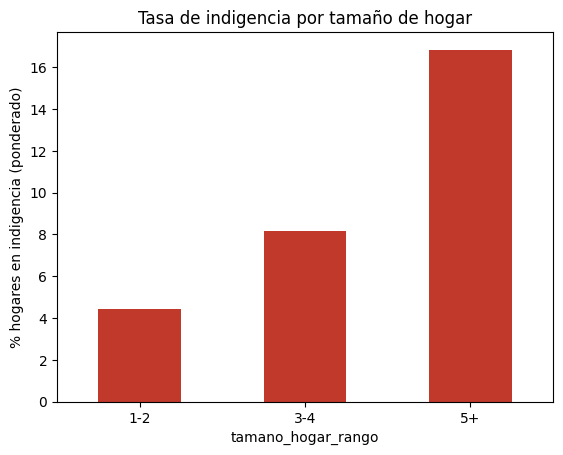

In [27]:
query_tamano = """
SELECT h.tamano_hogar_rango, SUM(f.indigente * f.fex_c) / SUM(f.fex_c) * 100 AS pct_indigente
FROM fact_hogares f
JOIN dim_hogar h ON f.id_hogar = h.id_hogar
GROUP BY h.tamano_hogar_rango
ORDER BY h.tamano_hogar_rango
"""
tasas_tamano = pd.read_sql(text(query_tamano), engine)
print(tasas_tamano)

tasas_tamano.plot(x="tamano_hogar_rango", y="pct_indigente", kind="bar", color="#c0392b", legend=False)
plt.ylabel("% hogares en indigencia (ponderado)")
plt.title("Tasa de indigencia por tamaño de hogar")
plt.xticks(rotation=0)
plt.show()


In [28]:
# Correlación ponderada (nper vs. indigente), calculada directo en SQL
query_corr = """
WITH stats AS (
    SELECT
        SUM(nper * fex_c) / SUM(fex_c) AS mx,
        SUM(indigente * fex_c) / SUM(fex_c) AS my
    FROM fact_hogares
)
SELECT
    SUM((f.nper - s.mx) * (f.indigente - s.my) * f.fex_c) /
    SQRT(SUM(POWER(f.nper - s.mx, 2) * f.fex_c) * SUM(POWER(f.indigente - s.my, 2) * f.fex_c)) AS correlacion
FROM fact_hogares f, stats s
"""
r = pd.read_sql(text(query_corr), engine)["correlacion"][0]
print(f"Correlación ponderada (nper vs. indigente): {r:.3f}")


Correlación ponderada (nper vs. indigente): 0.153


### Pregunta 2 - Distribución geográfica y urbano/rural de bajos ingresos

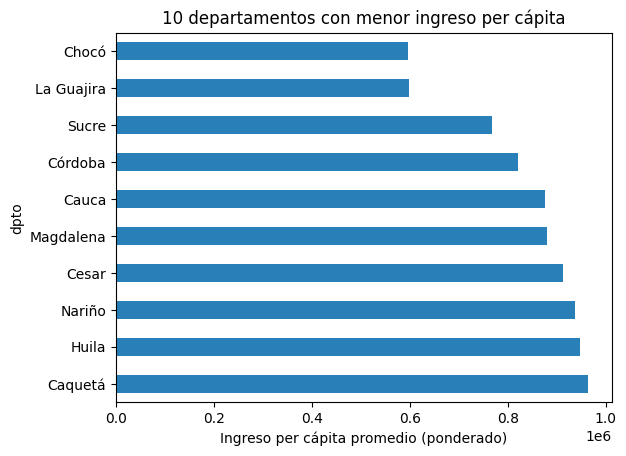

In [29]:
query_dpto = """
SELECT g.dpto, SUM(f.ingpcug * f.fex_c) / SUM(f.fex_c) AS ingreso_promedio
FROM fact_hogares f
JOIN dim_geografia g ON f.id_geografia = g.id_geografia
GROUP BY g.dpto
ORDER BY ingreso_promedio ASC
LIMIT 10
"""
ingreso_dpto = pd.read_sql(text(query_dpto), engine)

ingreso_dpto.plot(x="dpto", y="ingreso_promedio", kind="barh", color="#2980b9", legend=False)
plt.xlabel("Ingreso per cápita promedio (ponderado)")
plt.title("10 departamentos con menor ingreso per cápita")
plt.gca().invert_yaxis()
plt.show()


                pct_pobre  pct_indigente
tipo_zona                               
Ciudad capital      17.60           4.38
Resto urbano        23.30           7.58
Rural               32.30          14.77


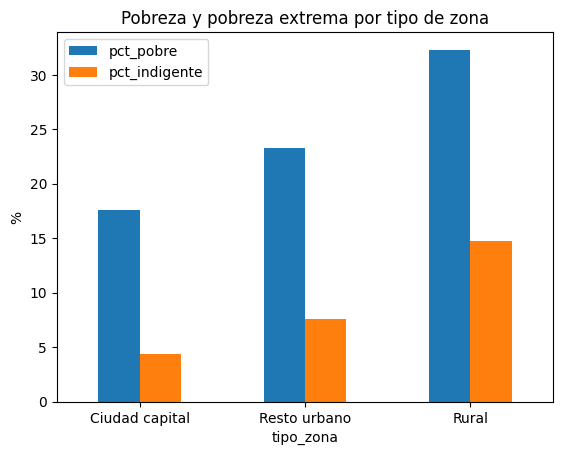

In [30]:
query_zona = """
SELECT g.tipo_zona,
       SUM(f.pobre * f.fex_c) / SUM(f.fex_c) * 100 AS pct_pobre,
       SUM(f.indigente * f.fex_c) / SUM(f.fex_c) * 100 AS pct_indigente
FROM fact_hogares f
JOIN dim_geografia g ON f.id_geografia = g.id_geografia
GROUP BY g.tipo_zona
"""
tasas_zona = pd.read_sql(text(query_zona), engine).set_index("tipo_zona")
print(tasas_zona)

tasas_zona.plot(kind="bar")
plt.ylabel("%")
plt.title("Pobreza y pobreza extrema por tipo de zona")
plt.xticks(rotation=0)
plt.show()


### Pregunta 3 - ¿Quiénes están en pobreza extrema y qué tan lejos están de salir?

Brecha mediana (ponderada) de los hogares en indigencia: 34.1% por debajo de la línea de indigencia


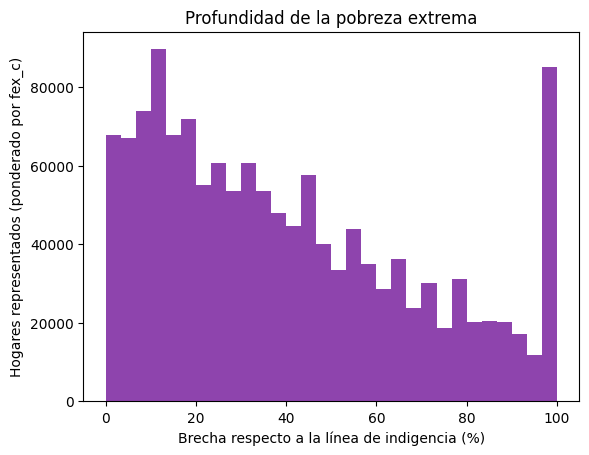

In [31]:
query_brecha = """
SELECT brecha_pct_indigencia, fex_c
FROM fact_hogares
WHERE indigente = 1
"""
indigentes = pd.read_sql(text(query_brecha), engine).sort_values("brecha_pct_indigencia")

# Mediana ponderada calculada directamente con pandas (peso acumulado), sin función auxiliar
indigentes["cum_peso"] = (indigentes["fex_c"].cumsum() - 0.5 * indigentes["fex_c"]) / indigentes["fex_c"].sum()
mediana_brecha = np.interp(0.5, indigentes["cum_peso"], indigentes["brecha_pct_indigencia"])
print(f"Brecha mediana (ponderada) de los hogares en indigencia: {mediana_brecha:.1f}% por debajo de la línea de indigencia")

plt.hist(indigentes["brecha_pct_indigencia"], bins=30, weights=indigentes["fex_c"], color="#8e44ad")
plt.xlabel("Brecha respecto a la línea de indigencia (%)")
plt.ylabel("Hogares representados (ponderado por fex_c)")
plt.title("Profundidad de la pobreza extrema")
plt.show()
